## Line plot

1. color palette for AR5 & AR6, from pyam package
2. example line plot

In [ ]:
# import necessary libraries
import pandas as pd
import pyam
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple
from matplotlib.legend_handler import HandlerBase
from matplotlib.patches import Rectangle


### 1.color palette for AR5 & AR6, from pyam package

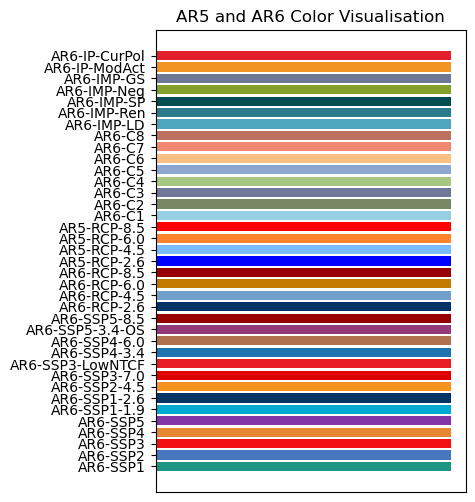

In [29]:
# To show the AR5 and AR6 color palette inside the pyam package
colors = pyam.plotting.PYAM_COLORS

plot_names = list(colors.keys())
plot_colors = list(colors.values())

plt.figure(figsize=(4,6))
plt.barh(plot_names, [1]*len(plot_names), color=plot_colors)
plt.gca().set_xticks([])
plt.gca().set_yticks(range(len(plot_names)))
plt.gca().set_yticklabels(plot_names)
plt.title("AR5 and AR6 Color Visualisation")
plt.show()

In [30]:
# Show the color names and their corresponding hex codes in a DataFrame
pd.DataFrame({"name":plot_names, "color": plot_colors})

,name,color
0,AR6-SSP1,#1e9583
1,AR6-SSP2,#4576be
2,AR6-SSP3,#f11111
3,AR6-SSP4,#e78731
4,AR6-SSP5,#8036a7
5,AR6-SSP1-1.9,#00a9cf
6,AR6-SSP1-2.6,#003466
7,AR6-SSP2-4.5,#f69320
8,AR6-SSP3-7.0,#df0000
9,AR6-SSP3-LowNTCF,#e61d25


### 2. example line plot

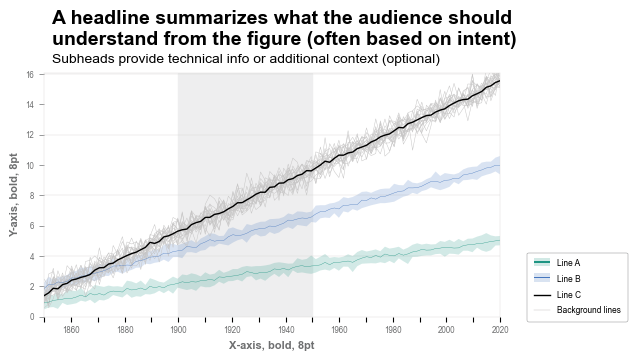

In [88]:
# -----------------------------
# Simulate data
# -----------------------------
np.random.seed(42)

# Original x
x = np.linspace(1850, 2020, 100)

# Normalize x to 0–1
x_norm = (x - x.min()) / (x.max() - x.min())

n_lines = 3
n_samples = 20

# Slopes now represent total increase across full range
slopes = [4, 8, 14]
intercepts = [1, 2, 1.5]

samples = [
    (intercepts[i] + slopes[i] * x_norm)[:, None] +
    0.3 * np.random.randn(len(x), n_samples)
    for i in range(n_lines)
]

# -----------------------------
# Figure setup
# -----------------------------
colors = ['#1e9583', '#4576be', '#000000']
labels = ['Line A', 'Line B', 'Line C']


fig, ax = plt.subplots(
    figsize=(6.5, 3.65),    # 165mm x 92.5mm
    facecolor='none'        # transparent figure background
)

# Set axes (graph area) background explicitly to white
ax.set_facecolor('white')

# Global axis limits
all_y = np.concatenate(samples, axis=1)
ax.set_xlim(x.min(), x.max())
ax.set_ylim(0, all_y.max())

# -----------------------------
# Background highlight
# -----------------------------
ax.axvspan(
    1900, 1950,        # x-range for the highlight
    color='#eeeeef', # color for the highlight
    alpha=1,           # no transparency
    edgecolor=None,    # no outline
    zorder=0           # back layer
)

# -----------------------------
# Plot Lines A & B (mean + Confidence Interval)
# -----------------------------
for i in range(2):
    mean = samples[i].mean(axis=1)
    p5 = np.percentile(samples[i], 5, axis=1)
    p95 = np.percentile(samples[i], 95, axis=1)

    # Fill CI range without outline
    ax.fill_between(
        x,
        p5,
        p95,
        color=colors[i],
        alpha=0.2,
        edgecolor='none',  # remove any outlines
        zorder=2
    )

    # Plot mean line on top
    ax.plot(
        x,
        mean,
        color=colors[i],
        linewidth=0.25, # 0.09 mm = 0.25 pt
        label=labels[i],
        zorder=5
    )

# -----------------------------
# Line C (scenarios + mean)
# -----------------------------
grey_line_color = '#c6c5c5'
black_mean = samples[2].mean(axis=1)

# Vectorized scenario generation: 20 scenario lines
scenarios = black_mean[:, None] + 0.5 * np.random.randn(len(x), n_samples)

# Plot light grey background scenario lines (no transparency)
ax.plot(
    x,
    scenarios,
    color=grey_line_color,    # light grey
    linewidth=0.34,      # 0.12 mm = 0.34 pt
    alpha=1,             # solid, no transparency
    zorder=2
)

# Plot the mean line for Line C on top of the scenarios
ax.plot(
    x,
    black_mean,
    color=colors[2],
    linewidth=1, # 0.35 mm = 1 pt
    label=labels[2],
    zorder=5
)

# -----------------------------
# Styling
# -----------------------------
label_grey = '#6e6f70'
grid_grey = '#d7d6d5'
border_lw = 0.283  # 0.1 mm = 0.283 pt

# Spines
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color(grid_grey)
    spine.set_linewidth(border_lw)

# X ticks (18 evenly spaced)
x_ticks = np.linspace(1850, 2020, 18)
ax.set_xticks(x_ticks)
ax.set_xticklabels([
    f"{int(t)}" if i % 2 else ""
    for i, t in enumerate(x_ticks)
])

# Tick styling
ax.tick_params(axis='x', colors='black',
               labelcolor=label_grey, labelsize=7, width=0.8)

ax.tick_params(axis='y', colors=label_grey,
               labelsize=7, width=0.5)

for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontname('Arial Narrow')

# Axis labels
label_font = dict(
    family='Arial',
    weight='bold',
    size=8,
    color=label_grey
)

ax.set_xlabel('X-axis, bold, 8pt', fontdict=label_font)
ax.set_ylabel('Y-axis, bold, 8pt', fontdict=label_font)

# Horizontal grid lines
for y in [4, 8, 12, 16]:
    ax.axhline(y, color=grid_grey,
               linewidth=border_lw, zorder=0)

# # -----------------------------
# # Legend
# # -----------------------------
class HandlerPatchLine(HandlerBase):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height,
                       fontsize, trans):

        patch, line = orig_handle

        rect_height = height * 1.5
        rect = Rectangle(
            (xdescent, ydescent),
            width,
            rect_height,
            facecolor=patch.get_facecolor(),
            edgecolor='none',
            alpha=patch.get_alpha(),
            transform=trans
        )

        y_center = ydescent + rect_height / 2.0
        line_height = line.get_linewidth()
        line_rect = Rectangle(
            (xdescent, y_center - line_height / 2),
            width,
            line_height,
            facecolor=line.get_color(),
            edgecolor='none',
            transform=trans
        )

        return [rect, line_rect]


axis_lw_pt = 0.34 # 0.12 mm = 0.34 pt

legend_handles = []
legend_labels = []

# Line A & B (ranges + lines)
for i in range(2):
    range_patch = Patch(
        facecolor=colors[i],
        edgecolor='none',
        alpha=0.2
    )

    mean_line = Line2D(
        [0], [0],
        color=colors[i],
        lw=1
    )

    legend_handles.append((range_patch, mean_line))
    legend_labels.append(labels[i])


# Black mean
black_line = Line2D(
    [0], [0],
    color=colors[2],
    lw= 1 # 0.35 mm = 1 pt
)

legend_handles.append(black_line)
legend_labels.append(labels[2])

# Grey background lines
grey_line = Line2D(
    [0], [0],
    color= grey_line_color,
    lw= 0.34 #0.12 mm = 0.34 pt
)

legend_handles.append(grey_line)
legend_labels.append("Background lines")

# Create the legend with the custom handler
legend = ax.legend(
    legend_handles,
    legend_labels,
    handler_map={tuple: HandlerPatchLine()},
    prop={'family': 'Arial', 'size': 6},
    loc='center left',
    bbox_to_anchor=(1.05, 0.12),
    frameon=True,
    borderpad=0.8,
    labelspacing=0.8,
    handlelength=2.0,
    handletextpad=0.8
)

legend.get_frame().set_linewidth(axis_lw_pt)
legend.get_frame().set_edgecolor(label_grey)
legend.get_frame().set_facecolor('white')

# -----------------------------
# Headline & Subhead
# -----------------------------
ax_left = ax.get_position().x0 * 0.7

fig.text(
    ax_left, 0.88,
    "A headline summarizes what the audience should\n"
    "understand from the figure (often based on intent)",
    fontsize=14, fontweight='bold',
    fontname='Arial', ha='left'
)

fig.text(
    ax_left, 0.83,
    "Subheads provide technical info or additional context (optional)",
    fontsize=10, fontname='Arial', ha='left'
)

fig.tight_layout(rect=[0, 0, 1, 0.85]) # leave space for headline & subhead
# -----------------------------
# Save the figure as SVG with transparent background
# -----------------------------
plt.savefig("./fig_svg/fig_line.svg")
plt.show()
plt.close()